# Marine Heatwave Analysis — South African Coastal Waters
## Using NOAA OISST v2.1 & the heatwaveR Package

The waters surrounding South Africa are among the most oceanographically dynamic on Earth. The collision of the warm Agulhas Current on the east coast and the cold Benguela Upwelling System on the west coast creates sharp thermal gradients and makes this region particularly sensitive to marine heatwave events.

In this section we apply the formal Hobday et al. (2016) marine heatwave detection methodology — the internationally accepted scientific standard — using prof. AJ Smit's `{heatwaveR}` package. Unlike the [simple anomaly map]() we made, this approach:

- Computes a **seasonally-varying climatological baseline** from the full 1982–present record at each location
- Identifies the **90th percentile threshold** above which SST must exceed to qualify as a marine heatwave
- Detects discrete **heatwave events** with their onset, peak, and decline dates
- Classifies events into **four intensity categories** — Moderate, Strong, Severe, and Extreme — based on multiples of the threshold exceedance
- Tracks long-term **trends** in MHW frequency, duration, and intensity

We will work at two scales: a **point analysis** for three ecologically important locations along the South African coast, and a **full spatial analysis** producing gridded maps of MHW characteristics across the region.

This analysis will be computationally heavy. We can expect the download loop for 40+ years of daily data to take anywhere from 20 minutes to over an hour depending on the internet connection and how busy the NOAA ERDDAP server is. The spatial detection will take another 30–60 minutes even with parallelisation. **Run it when you can leave it going.**

### Install and load libaries

In [ ]:
install.packages("heatwaveR")
install.packages("rerddap")
install.packages("ggnewscale")

In [2]:
library(tidyverse)
library(heatwaveR)
library(rerddap)       # Clean ERDDAP interface — much more reliable than download.file
library(terra)
library(sf)
library(rnaturalearth)
library(rnaturalearthhires)
library(scales)
library(patchwork)
library(lubridate)
library(showtext)

In [3]:
# Load elegant fonts
font_add_google("Playfair Display", "playfair")
font_add_google("Montserrat",       "mont")
showtext_auto()

In [4]:
options(
  repr.plot.width  = 14,
  repr.plot.height = 9,
  repr.plot.res    = 200
)

### Define region and parameters

We set a bounding box that captures the Benguela on the west, Agulhas on the east, and the Agulhas Bank — the broad continental shelf south of the country.

- Bounding box: South Africa coastal waters 15°E–37°E longitude, 36°S–25°S latitude

In [5]:
LON_MIN <- 15.0
LON_MAX <- 37.0
LAT_MIN <- -36.0
LAT_MAX <- -25.0

YEAR_START <- 1982
YEAR_END   <- as.integer(format(Sys.Date(), "%Y")) - 1  # up to last complete year

In [6]:
# Create data directory
dir.create("Data/OISST_SA", showWarnings = FALSE, recursive = TRUE)

In [8]:
cat(" Analysis parameters: \n")
cat("   Region   : ", LON_MIN, "–", LON_MAX, "°E, ",
    abs(LAT_MAX), "–", abs(LAT_MIN), "°S\n")
cat("   Period   : ", YEAR_START, "–", YEAR_END, "\n")
cat("   Years    : ", YEAR_END - YEAR_START + 1, "\n")

 Analysis parameters: 
   Region   :  15 – 37 °E,  25 – 36 °S
   Period   :  1982 – 2025 
   Years    :  44 


### Download OISST year by year

We use the `{rerddap}` package to query the NOAA ERDDAP server cleanly.

Downloading year by year means:
- If a download fails, only that year needs to be retried
- Memory stays manageable — we never load the full record at once
- Progress is visible and files are cached locally

**Dataset:** ncdcOisst21Agg_LonPM180

**Variable:** sst (sea surface temperature, °C)

**Resolution:** 0.25° daily \n

In [9]:
OisstInfo <- rerddap::info("ncdcOisst21Agg_LonPM180",
                            url = "https://coastwatch.pfeg.noaa.gov/erddap/")

In [10]:
print(OisstInfo)

<ERDDAP(TM) info> ncdcOisst21Agg_LonPM180 
 Base URL: https://coastwatch.pfeg.noaa.gov/erddap 
 Dataset Type: griddap 
 Dimensions (range):  
     time: (1981-09-01T12:00:00Z, 2026-02-07T12:00:00Z) 
     zlev: (0.0, 0.0) 
     latitude: (-89.875, 89.875) 
     longitude: (-179.875, 179.875) 
 Variables:  
     anom: 
         Units: degree_C 
     err: 
         Units: degree_C 
     ice: 
         Units: 1 
     sst: 
         Units: degree_C 


In [12]:
download_oisst_year <- function(year) {

  out_file <- paste0("Data/OISST_SA/oisst_sa_", year, ".rds")

  if (file.exists(out_file)) {
    cat("   Year", year, "already downloaded — skipping.\n")
    return(invisible(NULL))
  }

  cat("   Downloading year", year, "…")

  start_date <- paste0(year, "-01-01")
  end_date   <- paste0(year, "-12-31")

  result <- tryCatch({
    dat <- rerddap::griddap(
      OisstInfo,
      time     = c(start_date, end_date),
      zlev     = c(0, 0),
      latitude  = c(LAT_MIN, LAT_MAX),
      longitude = c(LON_MIN, LON_MAX),
      fields   = "sst"
    )

    # Clean and save
    clean <- dat$data %>%
      as_tibble() %>%
      rename(lon = longitude, lat = latitude, t = time, temp = sst) %>%
      mutate(
        t    = as.Date(t),
        lon  = round(lon, 2),
        lat  = round(lat, 2),
        temp = as.numeric(temp)
      ) %>%
      filter(!is.na(temp))

    saveRDS(clean, out_file)
    cat(" done. Rows:", nrow(clean), "\n")
    return(invisible(NULL))

  }, error = function(e) {
    cat(" FAILED:", conditionMessage(e), "\n")
    return(invisible(NULL))
  })
}

In [13]:
# Run the download loop — this will take a while for the full record
# Progress is printed for each year
cat("\n Downloading OISST 1982 ", YEAR_END, " ──────────────────────────\n")

walk(YEAR_START:YEAR_END, download_oisst_year)

cat("── Download complete \n")

info() output passed to x; setting base url to: https://coastwatch.pfeg.noaa.gov/erddap



 done. Rows: 689485 

info() output passed to x; setting base url to: https://coastwatch.pfeg.noaa.gov/erddap



 done. Rows: 689485 

info() output passed to x; setting base url to: https://coastwatch.pfeg.noaa.gov/erddap



...

 done. Rows: 687596 

info() output passed to x; setting base url to: https://coastwatch.pfeg.noaa.gov/erddap



 done. Rows: 689485 

info() output passed to x; setting base url to: https://coastwatch.pfeg.noaa.gov/erddap



 done. Rows: 687596 
── Download complete 


### Stack the full time series

Read all yearly RDS files and combine into one large tibble. We also add a coastal region label based on longitude — west coast (Benguela), south coast (Agulhas Bank), east coast (Agulhas Current).

In [14]:
RdsFiles <- list.files("Data/OISST_SA", pattern = "\\.rds$",
                        full.names = TRUE) %>% sort()

In [15]:
length(RdsFiles)

[1] 44

In [16]:
SST_Full <- map(RdsFiles, readRDS) %>%
  bind_rows() %>%
  arrange(lon, lat, t)

In [17]:
cat("   Total rows  :", nrow(SST_Full), "\n")
cat("   Date range  :", as.character(min(SST_Full$t)),
    "to", as.character(max(SST_Full$t)), "\n")
cat("   Grid cells  :", n_distinct(paste(SST_Full$lon, SST_Full$lat)), "\n")

   Total rows  : 30346785 
   Date range  : 1982-01-01 to 2025-12-31 
   Grid cells  : 1889 


### Define point locations for time series analysis

Three ecologically and economically important locations:

- Port Nolloth  — northern Benguela upwelling zone, west coast
- Cape Point    — transition zone between Benguela and Agulhas Bank
- Port Elizabeth (Gqeberha) — central Agulhas Bank, east of Cape Agulhas

In [18]:
PointLocations <- tribble(
  ~site,            ~lon,   ~lat,    ~system,
  "Port Nolloth",   16.75, -29.25,  "Benguela",
  "Cape Point",     18.75, -34.50,  "Transition",
  "Gqeberha",       25.75, -33.75,  "Agulhas Bank"
)

In [19]:
print(PointLocations)

# A tibble: 3 × 4
  site           lon   lat system      
  <chr>        <dbl> <dbl> <chr>       
1 Port Nolloth  16.8 -29.2 Benguela    
2 Cape Point    18.8 -34.5 Transition  
3 Gqeberha      25.8 -33.8 Agulhas Bank


In [20]:
# Extract the nearest grid cell for each site
extract_point_ts <- function(site_row, full_data) {

  # Find nearest available lon/lat in the grid
  grid_lons <- unique(full_data$lon)
  grid_lats <- unique(full_data$lat)

  nearest_lon <- grid_lons[which.min(abs(grid_lons - site_row$lon))]
  nearest_lat <- grid_lats[which.min(abs(grid_lats - site_row$lat))]

  full_data %>%
    filter(lon == nearest_lon, lat == nearest_lat) %>%
    arrange(t) %>%
    mutate(site = site_row$site, system = site_row$system)
}

In [21]:
PointTS_List <- pmap(PointLocations, function(site, lon, lat, system) {
  extract_point_ts(
    tibble(site = site, lon = lon, lat = lat, system = system),
    SST_Full
  )
})

In [22]:
names(PointTS_List) <- PointLocations$site

In [23]:
walk2(names(PointTS_List), PointTS_List,
      ~cat("  ", .x, ":", nrow(.y), "days\n"))

   Port Nolloth : 16065 days
   Cape Point : 16065 days
   Gqeberha : 16065 days


### `{heatwaveR}` event detection at each point

- `ts2clm()`  — computes the seasonal climatology and 90th percentile threshold using a 30-year baseline period and 11-day smoothing window
- `detect_event()` — identifies MHW events where SST exceeds threshold for >=5 days

We run this for each of the three sites and store both the full daily climatology output and the event catalogue.

In [24]:
detect_mhw <- function(ts_df) {

  # heatwaveR expects columns named 't' (Date) and 'temp' (numeric)
  clim <- ts2clm(
    data      = ts_df %>% select(t, temp),
    climatologyPeriod = c("1982-01-01", "2011-12-31"),
    pctile    = 90,       # 90th percentile — standard MHW definition
    windowHalfWidth = 5   # 11-day smoothing window (±5 days)
  )

  events <- detect_event(clim)
  events
}

In [25]:
# Run heatwave detection
MHW_Results <- map(PointTS_List, detect_mhw)

In [44]:
# Check the structure of MHW_Results
cat(" Structure of MHW_Results: \n")
cat("Class of MHW_Results:        ", class(MHW_Results), "\n")
cat("Class of MHW_Results[[1]]:   ", class(MHW_Results[[1]]), "\n")
cat("Names of MHW_Results[[1]]:   ", names(MHW_Results[[1]]), "\n")

 Structure of MHW_Results: 
Class of MHW_Results:         list 
Class of MHW_Results[[1]]:    list 
Names of MHW_Results[[1]]:    climatology event 


In [26]:
# Extract event catalogues
EventCatalogues <- imap(MHW_Results, function(result, site_name) {
  result$event %>%
    as_tibble() %>%
    mutate(site = site_name)
}) %>% bind_rows()

In [27]:
# Events detected
EventCatalogues %>%
  count(site) %>%
  print()

# A tibble: 3 × 2
  site             n
  <chr>        <int>
1 Cape Point     124
2 Gqeberha        80
3 Port Nolloth    91


In [30]:
# Check what columns are actually available in `EventCatalogues`
print(names(EventCatalogues))

 [1] "event_no"                       "index_start"                   
 [3] "index_peak"                     "index_end"                     
 [5] "duration"                       "date_start"                    
 [7] "date_peak"                      "date_end"                      
 [9] "intensity_mean"                 "intensity_max"                 
[11] "intensity_var"                  "intensity_cumulative"          
[13] "intensity_mean_relThresh"       "intensity_max_relThresh"       
[15] "intensity_var_relThresh"        "intensity_cumulative_relThresh"
[17] "intensity_mean_abs"             "intensity_max_abs"             
[19] "intensity_var_abs"              "intensity_cumulative_abs"      
[21] "rate_onset"                     "rate_decline"                  
[23] "site"                          


In [31]:
# Top 5 most intense events (peak intensity)
EventCatalogues %>%
  arrange(desc(intensity_max)) %>%
  select(site, date_start, date_peak, date_end,
         duration, intensity_max, intensity_cumulative) %>%
  slice_head(n = 5) %>%
  print()

# A tibble: 5 × 7
  site         date_start date_peak  date_end   duration intensity_max
  <chr>        <date>     <date>     <date>        <dbl>         <dbl>
1 Port Nolloth 2016-01-18 2016-01-27 2016-02-21       35          4.39
2 Port Nolloth 2009-01-02 2009-01-08 2009-01-15       14          3.95
3 Port Nolloth 1988-03-10 1988-03-15 1988-03-22       13          3.95
4 Port Nolloth 2024-01-23 2024-02-07 2024-02-09       18          3.94
5 Cape Point   2021-03-05 2021-03-10 2021-03-11        7          3.84
# ℹ 1 more variable: intensity_cumulative <dbl>


We add MHW categories properly using the `category()` function. This classifes each event into Moderate / Strong / Severe / Extreme.

In [33]:
MHW_Categories <- imap(MHW_Results, function(result, site_name) {
  category(result, name = site_name) %>%
    as_tibble() %>%
    mutate(site = site_name)
}) %>% bind_rows()

In [34]:
# Category breakdown per site
MHW_Categories %>%
  count(site, category) %>%
  arrange(site, category) %>%
  print()

# A tibble: 8 × 3
  site         category       n
  <chr>        <chr>      <int>
1 Cape Point   I Moderate   102
2 Cape Point   II Strong     21
3 Cape Point   III Severe     1
4 Gqeberha     I Moderate    58
5 Gqeberha     II Strong     22
6 Port Nolloth I Moderate    61
7 Port Nolloth II Strong     28
8 Port Nolloth III Severe     2


In [35]:
# Merge categories back into EventCatalogues for downstream use
EventCatalogues <- EventCatalogues %>%
  left_join(
    MHW_Categories %>% select(site, event_no, category),
    by = c("site", "event_no")
  )

In [36]:
# Top 5 most intense events with categories
EventCatalogues %>%
  arrange(desc(intensity_max)) %>%
  select(site, date_start, date_peak, date_end,
         duration, intensity_max, intensity_cumulative, category) %>%
  slice_head(n = 5) %>%
  print()

# A tibble: 5 × 8
  site         date_start date_peak  date_end   duration intensity_max
  <chr>        <date>     <date>     <date>        <dbl>         <dbl>
1 Port Nolloth 2016-01-18 2016-01-27 2016-02-21       35          4.39
2 Port Nolloth 2009-01-02 2009-01-08 2009-01-15       14          3.95
3 Port Nolloth 1988-03-10 1988-03-15 1988-03-22       13          3.95
4 Port Nolloth 2024-01-23 2024-02-07 2024-02-09       18          3.94
5 Cape Point   2021-03-05 2021-03-10 2021-03-11        7          3.84
# ℹ 2 more variables: intensity_cumulative <dbl>, category <chr>


### Event plots

`{heatwaveR}` has a built-in `event_line()` and `lolli_plot()` function. We will use these for the most intense events at each site, then build our own styled versions because why not.

In [37]:
# Find the most intense event per site for the event line plot
TopEvents <- EventCatalogues %>%
  group_by(site) %>%
  slice_max(intensity_cumulative, n = 1) %>%
  ungroup()

In [38]:
print(TopEvents %>% select(site, date_start, date_end, duration,
                            intensity_max, category))

# A tibble: 3 × 6
  site         date_start date_end   duration intensity_max category  
  <chr>        <date>     <date>        <dbl>         <dbl> <chr>     
1 Cape Point   2012-02-13 2012-03-23       40          2.74 I Moderate
2 Gqeberha     2024-12-06 2025-01-30       56          2.94 II Strong 
3 Port Nolloth 2016-01-18 2016-02-21       35          4.39 III Severe


### Build styled event line plots for each site

In [45]:
plot_event_line <- function(mhw_result, site_name) {

  top <- mhw_result$event %>%
    as_tibble() %>%
    slice_max(intensity_cumulative, n = 1)

  focus_year <- year(top$date_peak)

  event_line(
    mhw_result,
    spread     = 180,
    metric     = intensity_max,
    start_date = as.Date(paste0(focus_year, "-01-01")),
    end_date   = as.Date(paste0(focus_year, "-12-31"))
  ) +
  labs(
    title    = site_name,
    subtitle = paste0(
      "Peak event: ", top$date_start, " → ", top$date_end,
      "  ·  ", top$duration, " days",
      "  ·  +", round(top$intensity_max, 2), "°C above threshold"
    ),
    x = NULL, y = "SST (°C)"
  ) +
  theme_minimal(base_family = "mont") +
  theme(
    plot.background  = element_rect(fill = "white",   colour = NA),
    panel.background = element_rect(fill = "#f8f9fa", colour = NA),
    panel.grid.major = element_line(colour = "#e8e8e8", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    panel.border     = element_rect(colour = "grey70", fill = NA, linewidth = 0.5),
    plot.title       = element_text(family = "playfair", face = "bold",
                                    size = 12, colour = "#1a1a2e"),
    plot.subtitle    = element_text(size = 8, colour = "#4a4a6a"),
    axis.text        = element_text(colour = "#5a5a7a", size = 8),
    axis.title       = element_text(colour = "#1a1a2e", size = 9),
    legend.position  = "bottom",
    plot.margin      = margin(10, 14, 8, 12)
  )
}

In [47]:
# Simple named map — one site at a time, no pmap complexity
EventLinePlots <- imap(MHW_Results, plot_event_line)

EventLinePanel <- wrap_plots(EventLinePlots, ncol = 1) +
  plot_annotation(
    title    = "Most Intense Marine Heatwave Event at Each Site",
    subtitle = "Shading = MHW categories: Moderate / Strong / Severe / Extreme",
    theme    = theme(
      plot.background = element_rect(fill = "white", colour = NA),
      plot.title      = element_text(family = "playfair", face = "bold",
                                     size = 16, colour = "#1a1a2e"),
      plot.subtitle   = element_text(family = "mont", size = 10,
                                     colour = "#4a4a6a")
    )
  )

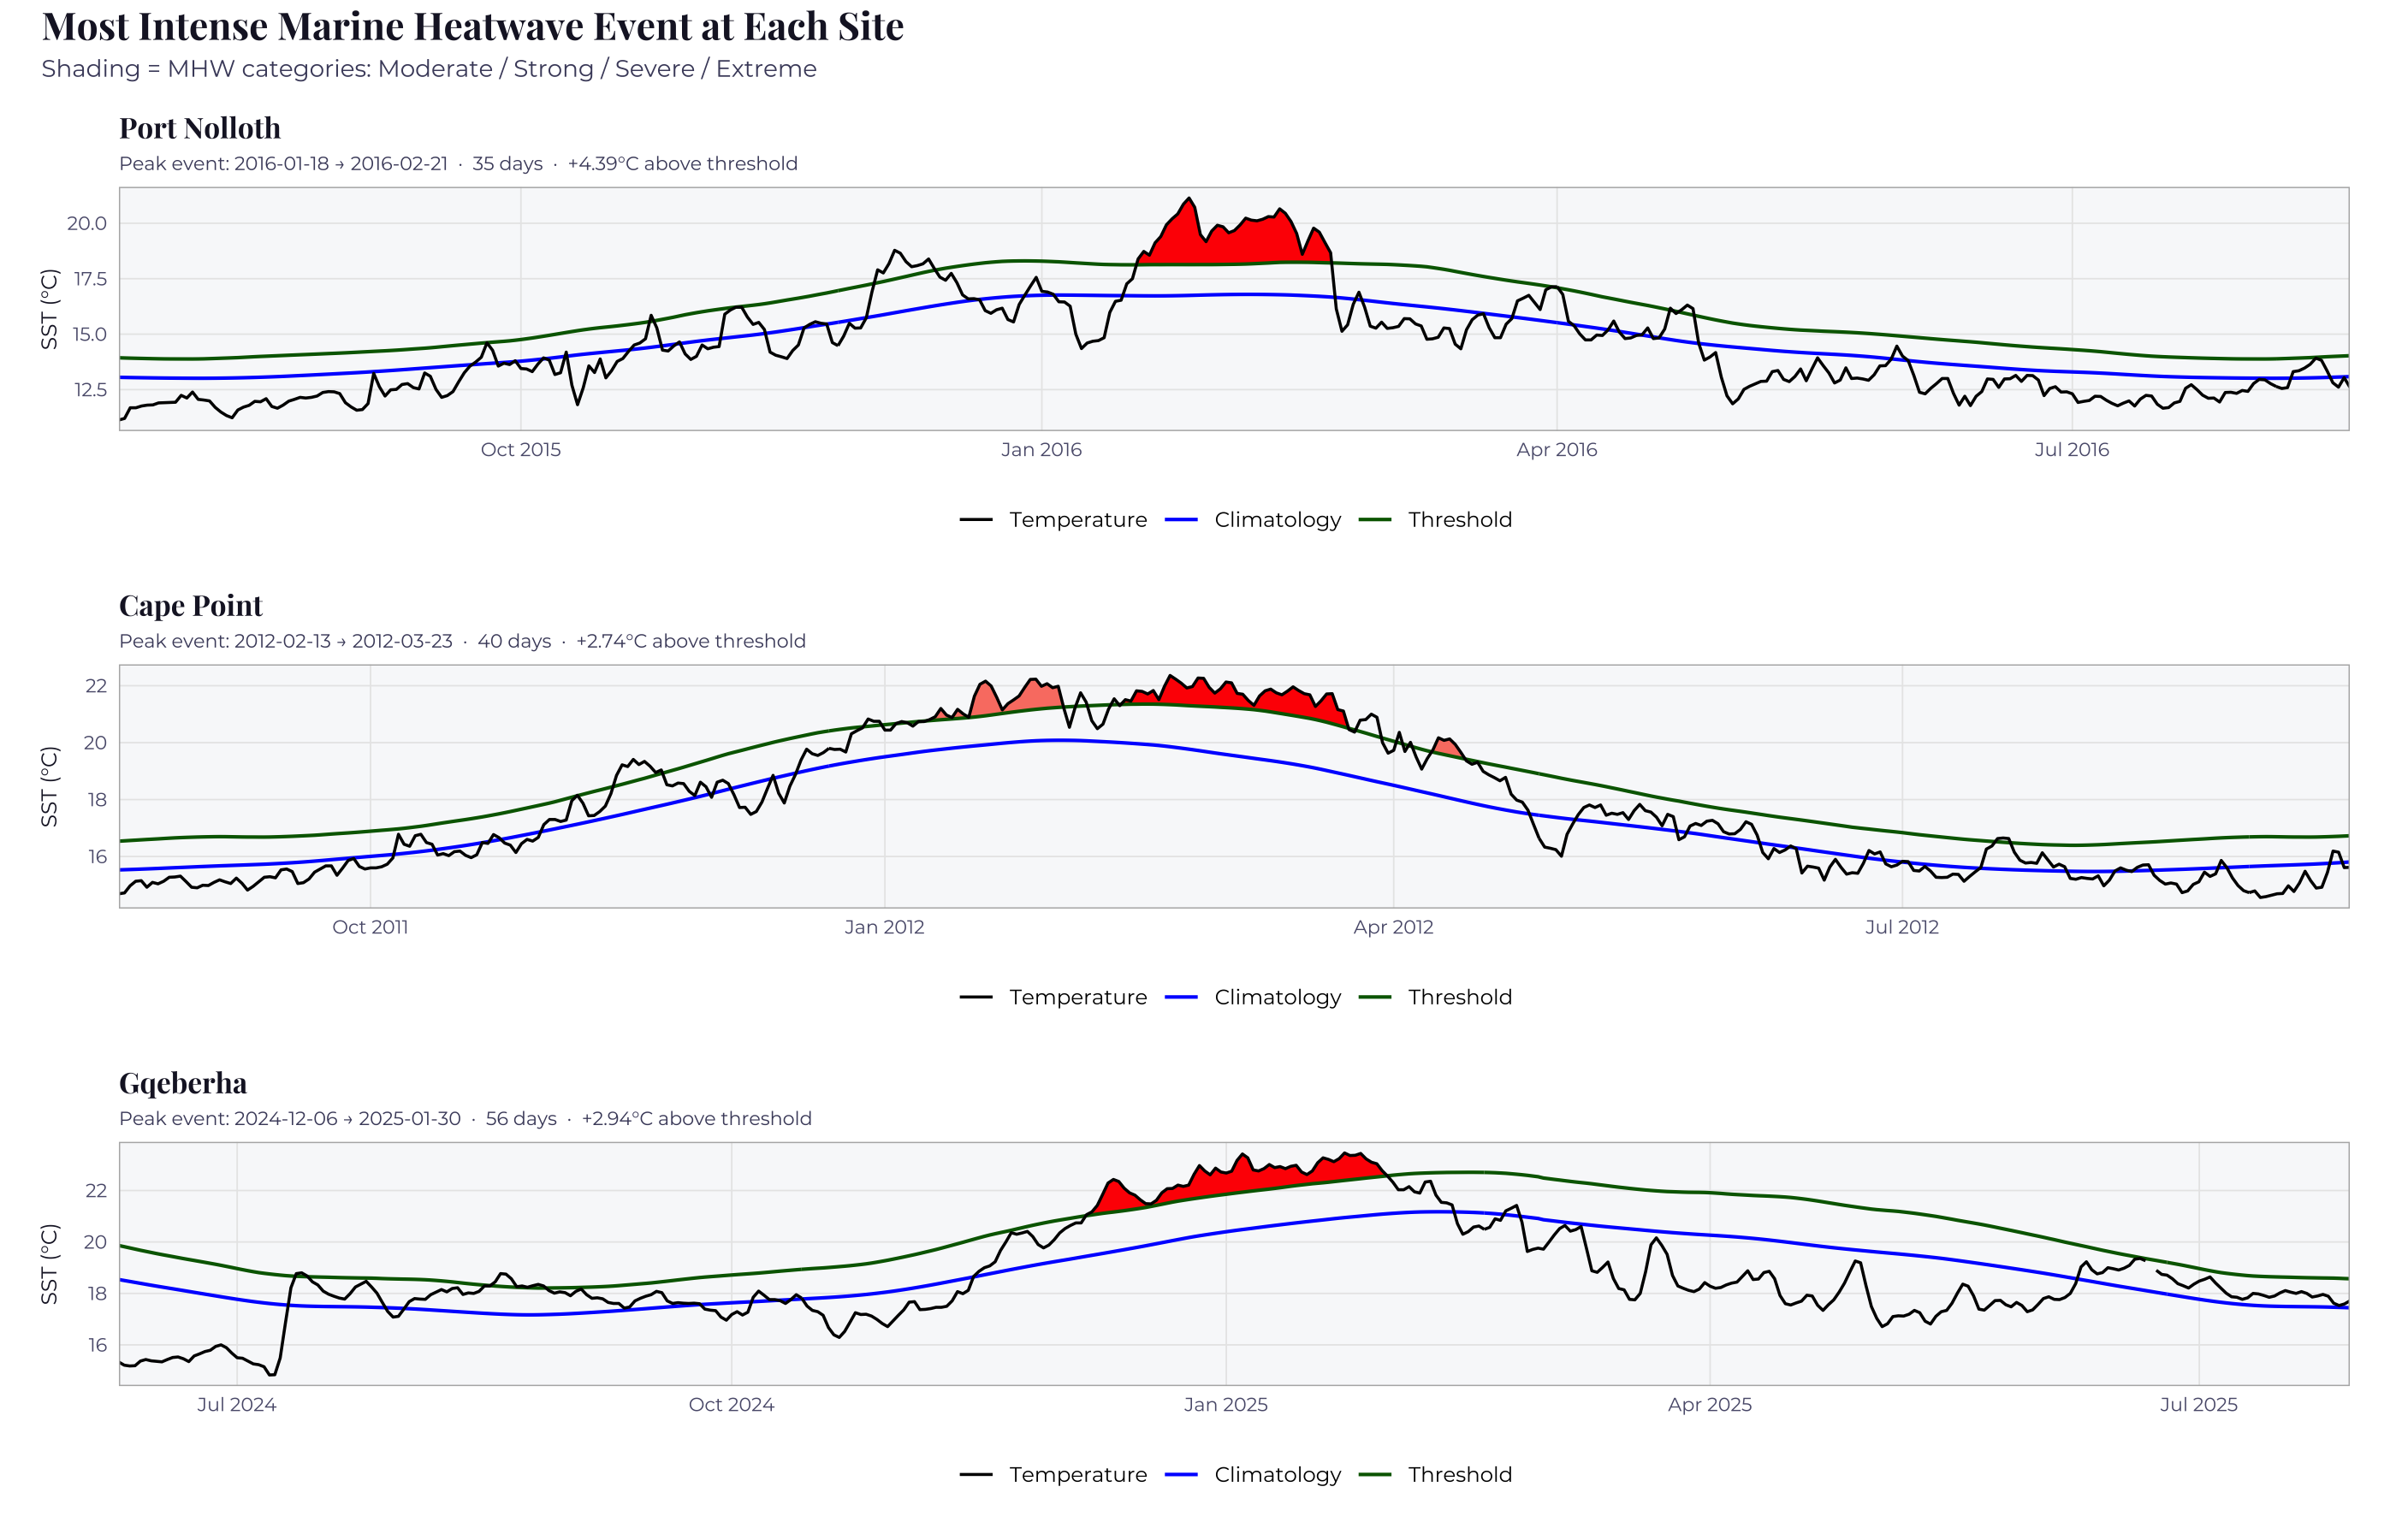

In [48]:
print(EventLinePanel)

### Trend analysis

We compute annual MHW metrics for each site and fit a linear trend to see whether or not the MHWs are getting worse.

**Key metrics:** total MHW days per year, mean duration, mean intensity.

In [49]:
AnnualMetrics <- EventCatalogues %>%
  mutate(year = year(date_start)) %>%
  group_by(site, year) %>%
  summarise(
    n_events      = n(),
    total_days    = sum(duration),
    mean_duration = mean(duration),
    mean_intensity = mean(intensity_max),
    max_intensity  = max(intensity_max),
    .groups = "drop"
  )

In [50]:
# Fill years with zero events (important for trend calculation)
AllYears <- expand_grid(
  site = unique(AnnualMetrics$site),
  year = YEAR_START:YEAR_END
)

In [51]:
AnnualMetrics_Full <- AllYears %>%
  left_join(AnnualMetrics, by = c("site", "year")) %>%
  replace_na(list(n_events = 0, total_days = 0,
                  mean_duration = 0, mean_intensity = 0, max_intensity = 0))

In [52]:
# Plot total MHW days per year with trend line
TrendPlot <- AnnualMetrics_Full %>%
  ggplot(aes(x = year, y = total_days, colour = site)) +
  geom_line(alpha = 0.5, linewidth = 0.6) +
  geom_point(size = 1.5, alpha = 0.7) +
  geom_smooth(
    method    = "lm",
    formula   = y ~ x,
    se        = TRUE,
    linewidth = 1,
    alpha     = 0.15
  ) +
  scale_colour_manual(
    values = c(
      "Port Nolloth" = "#2980b9",
      "Cape Point"   = "#27ae60",
      "Gqeberha"     = "#c0392b"
    ),
    name = "Site"
  ) +
  scale_fill_manual(
    values = c(
      "Port Nolloth" = "#2980b9",
      "Cape Point"   = "#27ae60",
      "Gqeberha"     = "#c0392b"
    ),
    guide = "none"
  ) +
  scale_x_continuous(breaks = seq(1982, YEAR_END, by = 5)) +
  labs(
    title    = "Annual Marine Heatwave Days — South African Coast",
    subtitle = "Total number of days per year where SST exceeded the 90th percentile threshold for ≥ 5 consecutive days",
    x        = NULL,
    y        = "Total MHW days per year",
    caption  = "Linear trend fitted by OLS · Shading = 95% confidence interval"
  ) +
  facet_wrap(~site, ncol = 1, scales = "free_y") +
  theme_minimal(base_family = "mont") +
  theme(
    plot.background   = element_rect(fill = "white", colour = NA),
    panel.background  = element_rect(fill = "#f8f9fa", colour = NA),
    panel.grid.major  = element_line(colour = "#e8e8e8", linewidth = 0.3),
    panel.grid.minor  = element_blank(),
    panel.border      = element_rect(colour = "grey70", fill = NA, linewidth = 0.5),
    strip.background  = element_rect(fill = "#1a1a2e", colour = NA),
    strip.text        = element_text(colour = "white", family = "mont",
                                     face = "bold", size = 9),
    plot.title        = element_text(family = "playfair", face = "bold",
                                     size = 14, colour = "#1a1a2e",
                                     margin = margin(b = 4)),
    plot.subtitle     = element_text(size = 8.5, colour = "#4a4a6a",
                                     margin = margin(b = 10)),
    plot.caption      = element_text(size = 7.5, colour = "#7a7a9a"),
    axis.text         = element_text(colour = "#5a5a7a", size = 8),
    axis.title        = element_text(colour = "#1a1a2e", size = 9),
    legend.position   = "none",
    plot.margin       = margin(14, 16, 12, 14)
  )

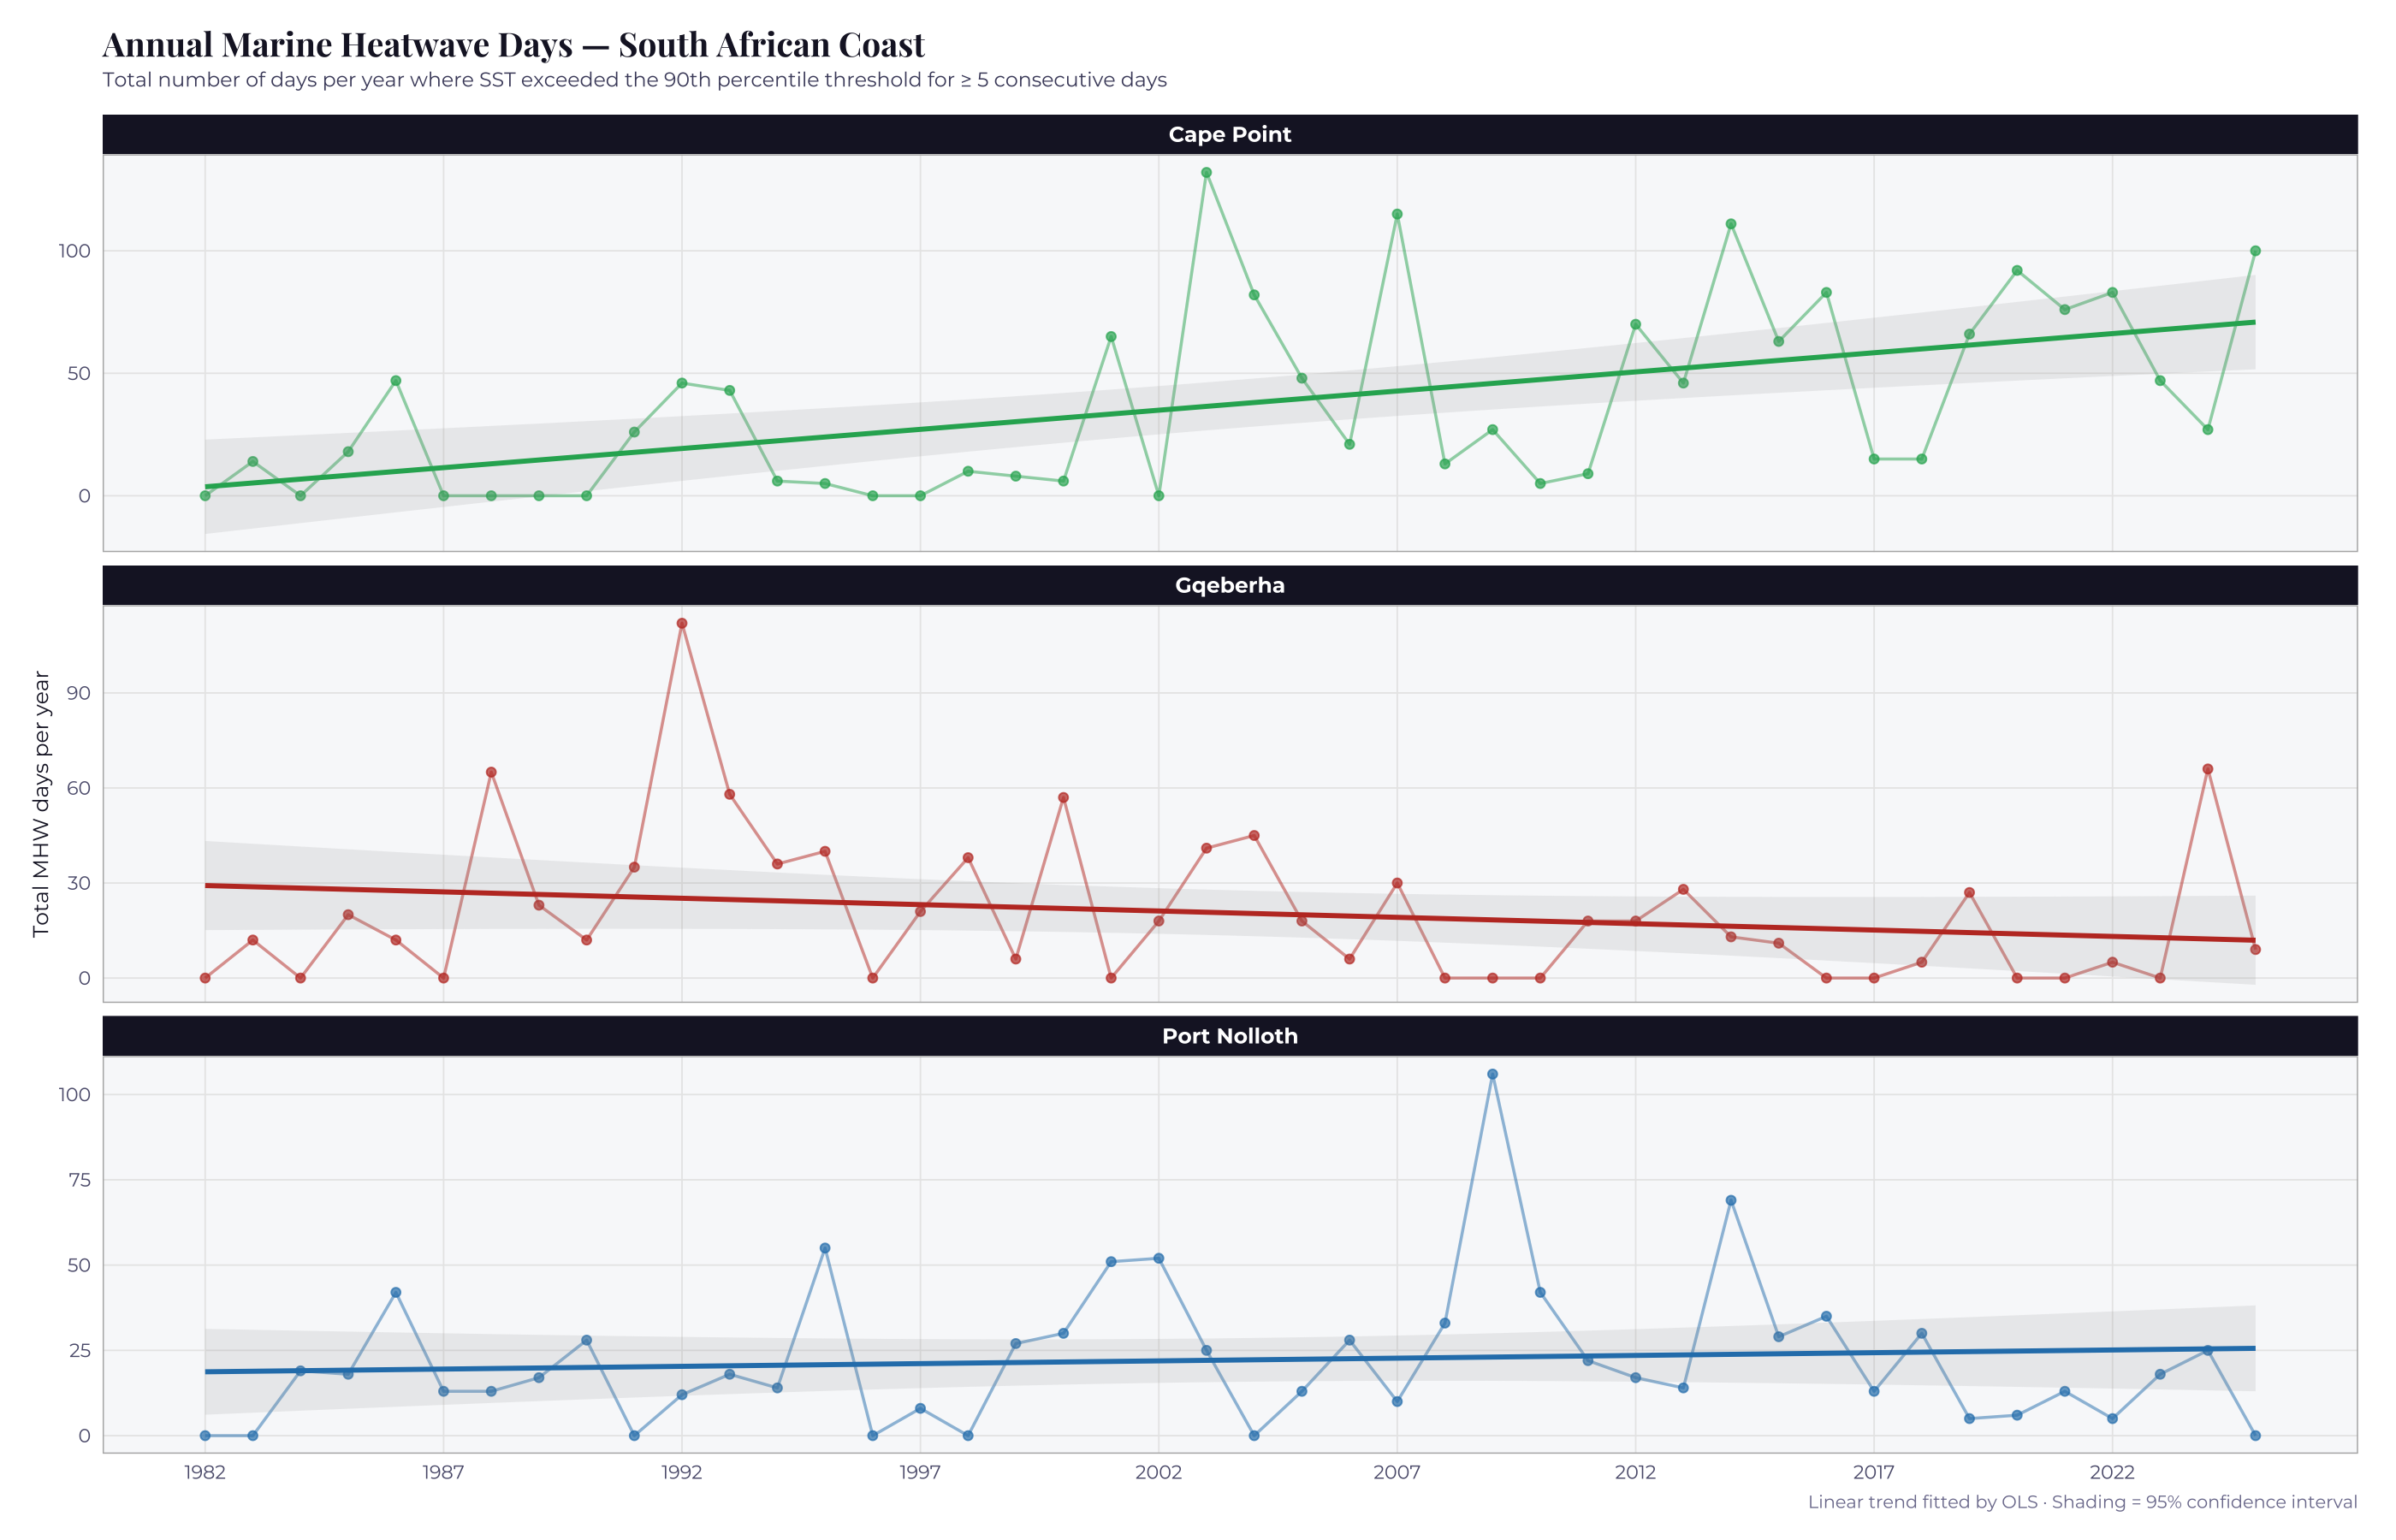

In [53]:
print(TrendPlot)

In [54]:
# Print trend slopes
cat("\n Linear trend in annual MHW days (days/decade) \n")
AnnualMetrics_Full %>%
  group_by(site) %>%
  summarise(
    slope_per_decade = round(coef(lm(total_days ~ year))[2] * 10, 2),
    .groups = "drop"
  ) %>%
  print()


 Linear trend in annual MHW days (days/decade) 
# A tibble: 3 × 2
  site         slope_per_decade
  <chr>                   <dbl>
1 Cape Point              15.6 
2 Gqeberha                -4.01
3 Port Nolloth             1.6 


### Spatial MHW detection

Now we run `{heatwaveR}` at every grid cell in the domain. This is the computationally heavy step — we parallelise across grid cells using the `{future}` + `{furrr}` packages to use multiple CPU cores.

The strategy here is to nest the data by grid cell, apply detect_mhw to each nest, then extract the summary statistics we want for mapping.

In [56]:
# install.packages("future")
# install.packages("furrr")

library(furrr)
library(future)

Loading required package: future



In [57]:
# Use all available cores minus one to keep the system responsive
NWorkers <- max(1, parallel::detectCores() - 1)
plan(multisession, workers = NWorkers)

In [58]:
cat("\n Running spatial MHW detection on", NWorkers, "cores \n")
cat("   Grid cells to process:",
    n_distinct(paste(SST_Full$lon, SST_Full$lat)), "\n")
cat("   This will take several minutes…\n")


 Running spatial MHW detection on 9 cores 
   Grid cells to process: 1889 
   This will take several minutes…


I do not know about you but my computer has 10 cores, as you can see above only 9 out of the 10 will be used.

Lets proceed to extract summary statistics per grid cell rather than storing full event catalogues — this keeps memory manageable for a spatial grid.

In [59]:
detect_mhw_summary <- function(ts_df) {
  tryCatch({
    clim <- ts2clm(
      data              = ts_df %>% select(t, temp),
      climatologyPeriod = c("1982-01-01", "2011-12-31"),
      pctile            = 90,
      windowHalfWidth   = 5
    )
    events <- detect_event(clim)$event %>% as_tibble()

    # Return grid-level summary metrics
    tibble(
      n_events          = nrow(events),
      mean_duration     = mean(events$duration,              na.rm = TRUE),
      mean_intensity    = mean(events$intensity_max,          na.rm = TRUE),
      max_intensity     = max(events$intensity_max,           na.rm = TRUE),
      total_mhw_days    = sum(events$duration,               na.rm = TRUE),
      mean_cum_intensity = mean(events$intensity_cumulative,  na.rm = TRUE),
      trend_days        = coef(lm(
        total_days ~ year,
        data = events %>%
          mutate(year = year(date_start)) %>%
          count(year, wt = duration, name = "total_days") %>%
          right_join(tibble(year = 1982:2011), by = "year") %>%
          replace_na(list(total_days = 0))
      ))[2] * 10  # slope per decade
    )
  }, error = function(e) {
    tibble(
      n_events = NA_real_, mean_duration = NA_real_,
      mean_intensity = NA_real_, max_intensity = NA_real_,
      total_mhw_days = NA_real_, mean_cum_intensity = NA_real_,
      trend_days = NA_real_
    )
  })
}

In [60]:
# Nest, process, unnest
SpatialMHW <- SST_Full %>%
  group_by(lon, lat) %>%
  nest() %>%
  mutate(mhw = future_map(data, detect_mhw_summary,
                           .progress = TRUE,
                           .options  = furrr_options(seed = TRUE))) %>%
  unnest(mhw) %>%
  select(-data) %>%
  ungroup()

In [61]:
plan(sequential)  # release parallel workers

In [62]:
cat("\n Spatial detection complete \n")
cat("   Grid cells processed:", nrow(SpatialMHW), "\n")
cat("   Cells with events   :", sum(!is.na(SpatialMHW$n_events)), "\n")


 Spatial detection complete 
   Grid cells processed: 1889 
   Cells with events   : 1889 


In [63]:
saveRDS(SpatialMHW, "Data/OISST_SA/spatial_mhw_summary.rds")

### Spatial maps

We build four map panels showing different MHW characteristics across the grid. Each panel uses the same basemap — high-res SA coastline on a clean white background.

In [64]:
SA_Coast <- ne_countries(
  scale       = "large",
  country     = c("South Africa", "Namibia", "Mozambique",
                  "Zimbabwe", "Botswana", "Lesotho", "Eswatini"),
  returnclass = "sf"
) %>% st_make_valid()

In [65]:
SA_Coastline <- ne_coastline(scale = "large", returnclass = "sf")

In [66]:
# Point locations for the three study sites
Sites_Sf <- PointLocations %>%
  st_as_sf(coords = c("lon", "lat"), crs = 4326)

In [67]:
# Shared map theme
MapTheme <- theme_minimal(base_family = "mont") +
  theme(
    plot.background  = element_rect(fill = "white", colour = NA),
    panel.background = element_rect(fill = "#d6eaf8", colour = NA),
    panel.grid       = element_line(colour = "white", linewidth = 0.3),
    panel.border     = element_rect(colour = "grey40", fill = NA, linewidth = 0.6),
    plot.title       = element_text(family = "playfair", face = "bold",
                                    size = 11, colour = "#1a1a2e"),
    plot.subtitle    = element_text(size = 8, colour = "#4a4a6a"),
    axis.text        = element_text(colour = "#5a5a7a", size = 7),
    axis.title       = element_blank(),
    legend.position  = "bottom",
    legend.title     = element_text(size = 8, face = "bold", colour = "#1a1a2e"),
    legend.text      = element_text(size = 7.5, colour = "#4a4a6a"),
    legend.key.width = unit(1.5, "cm"),
    plot.margin      = margin(8, 10, 6, 10)
  )

In [89]:
# Shared layers function to avoid repetition
add_basemap <- function(p) {
  p +
    geom_sf(
      data         = SA_Coast,
      inherit.aes  = FALSE,
      fill         = "#e8dcc8",
      colour       = "grey40",
      linewidth    = 0.3
    ) +
    geom_sf(
      data         = SA_Coastline,
      inherit.aes  = FALSE,
      colour       = "grey30",
      linewidth    = 0.4
    ) +
    geom_sf(
      data         = Sites_Sf,
      inherit.aes  = FALSE,
      colour       = "black",
      fill         = "white",
      shape        = 21,
      size         = 2.5,
      stroke       = 1
    ) +
    geom_text(
      data         = PointLocations,
      inherit.aes  = FALSE,
      aes(x = lon, y = lat, label = site),
      nudge_y      = 0.4,
      size         = 2.5,
      family       = "mont",
      fontface     = "bold",
      colour       = "#1a1a2e"
    ) +
    coord_sf(
      xlim   = c(LON_MIN, LON_MAX),
      ylim   = c(LAT_MIN, LAT_MAX),
      expand = FALSE
    )
}

In [90]:
# Panel A — Total MHW days (1982–present)
PanelA <- add_basemap(
  SpatialMHW %>%
    ggplot(aes(x = lon, y = lat, fill = total_mhw_days)) +
    geom_raster()
) +
  scale_fill_gradientn(
    colours  = c("#fff9f0","#fdd49e","#fdbb84","#fc8d59",
                 "#ef6548","#d7301f","#990000"),
    name     = "Total MHW days",
    na.value = "grey85",
    guide    = guide_colourbar(
      title.position = "top", title.hjust = 0.5,
      barwidth = unit(4.5, "cm"), barheight = unit(0.4, "cm")
    )
  ) +
  labs(title    = "A  ·  Total MHW Days",
       subtitle = "Cumulative days above 90th percentile threshold, 1982–present") +
  MapTheme

# Panel B — Mean event duration
PanelB <- add_basemap(
  SpatialMHW %>%
    ggplot(aes(x = lon, y = lat, fill = mean_duration)) +
    geom_raster()
) +
  scale_fill_gradientn(
    colours  = c("#f7fbff","#c6dbef","#6baed6","#2171b5","#08306b"),
    name     = "Mean duration (days)",
    na.value = "grey85",
    guide    = guide_colourbar(
      title.position = "top", title.hjust = 0.5,
      barwidth = unit(4.5, "cm"), barheight = unit(0.4, "cm")
    )
  ) +
  labs(title    = "B  ·  Mean Event Duration",
       subtitle = "Average duration of detected MHW events per grid cell") +
  MapTheme

# Panel C — Mean peak intensity
PanelC <- add_basemap(
  SpatialMHW %>%
    ggplot(aes(x = lon, y = lat, fill = mean_intensity)) +
    geom_raster()
) +
  scale_fill_gradientn(
    colours  = c("#fff5f0","#fcbba1","#fc8d59","#ef3b2c","#99000d"),
    name     = "Mean peak intensity (°C)",
    na.value = "grey85",
    guide    = guide_colourbar(
      title.position = "top", title.hjust = 0.5,
      barwidth = unit(4.5, "cm"), barheight = unit(0.4, "cm")
    )
  ) +
  labs(title    = "C  ·  Mean Peak Intensity",
       subtitle = "Average maximum SST anomaly above threshold during events") +
  MapTheme

# Panel D — Trend in MHW days per decade
PanelD <- add_basemap(
  SpatialMHW %>%
    ggplot(aes(x = lon, y = lat, fill = trend_days)) +
    geom_raster()
) +
  scale_fill_gradientn(
    colours  = c("#2166ac","#92c5de","#f7f7f7","#f4a582","#b2182b"),
    values   = rescale(c(-10, -3, 0, 3, 10)),
    limits   = c(-12, 12),
    oob      = squish,
    name     = "Trend (days / decade)",
    na.value = "grey85",
    guide    = guide_colourbar(
      title.position = "top", title.hjust = 0.5,
      barwidth = unit(4.5, "cm"), barheight = unit(0.4, "cm")
    )
  ) +
  labs(title    = "D  ·  Trend in MHW Days",
       subtitle = "Linear trend in annual MHW days per decade · Red = increasing") +
  MapTheme

In [91]:
# Compose the four-panel spatial figure
SpatialFigure <- (PanelA | PanelB) / (PanelC | PanelD) +
  plot_annotation(
    title    = "Marine Heatwave Characteristics — South African Coastal Waters (1982–present)",
    subtitle = "NOAA OISST v2.1 · 0.25° resolution · Hobday et al. (2016) MHW definition · 90th percentile threshold",
    caption  = "heatwaveR (Smit et al. 2019) · Baseline: 1982–2011 · ● = study sites",
    theme    = theme(
      plot.background = element_rect(fill = "white", colour = NA),
      plot.title      = element_text(family = "playfair", face = "bold",
                                     size = 16, colour = "#1a1a2e",
                                     margin = margin(b = 4)),
      plot.subtitle   = element_text(family = "mont", size = 9.5,
                                     colour = "#4a4a6a", margin = margin(b = 8)),
      plot.caption    = element_text(family = "mont", size = 7.5,
                                     colour = "#7a7a9a", hjust = 0)
    )
  )

Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven ho

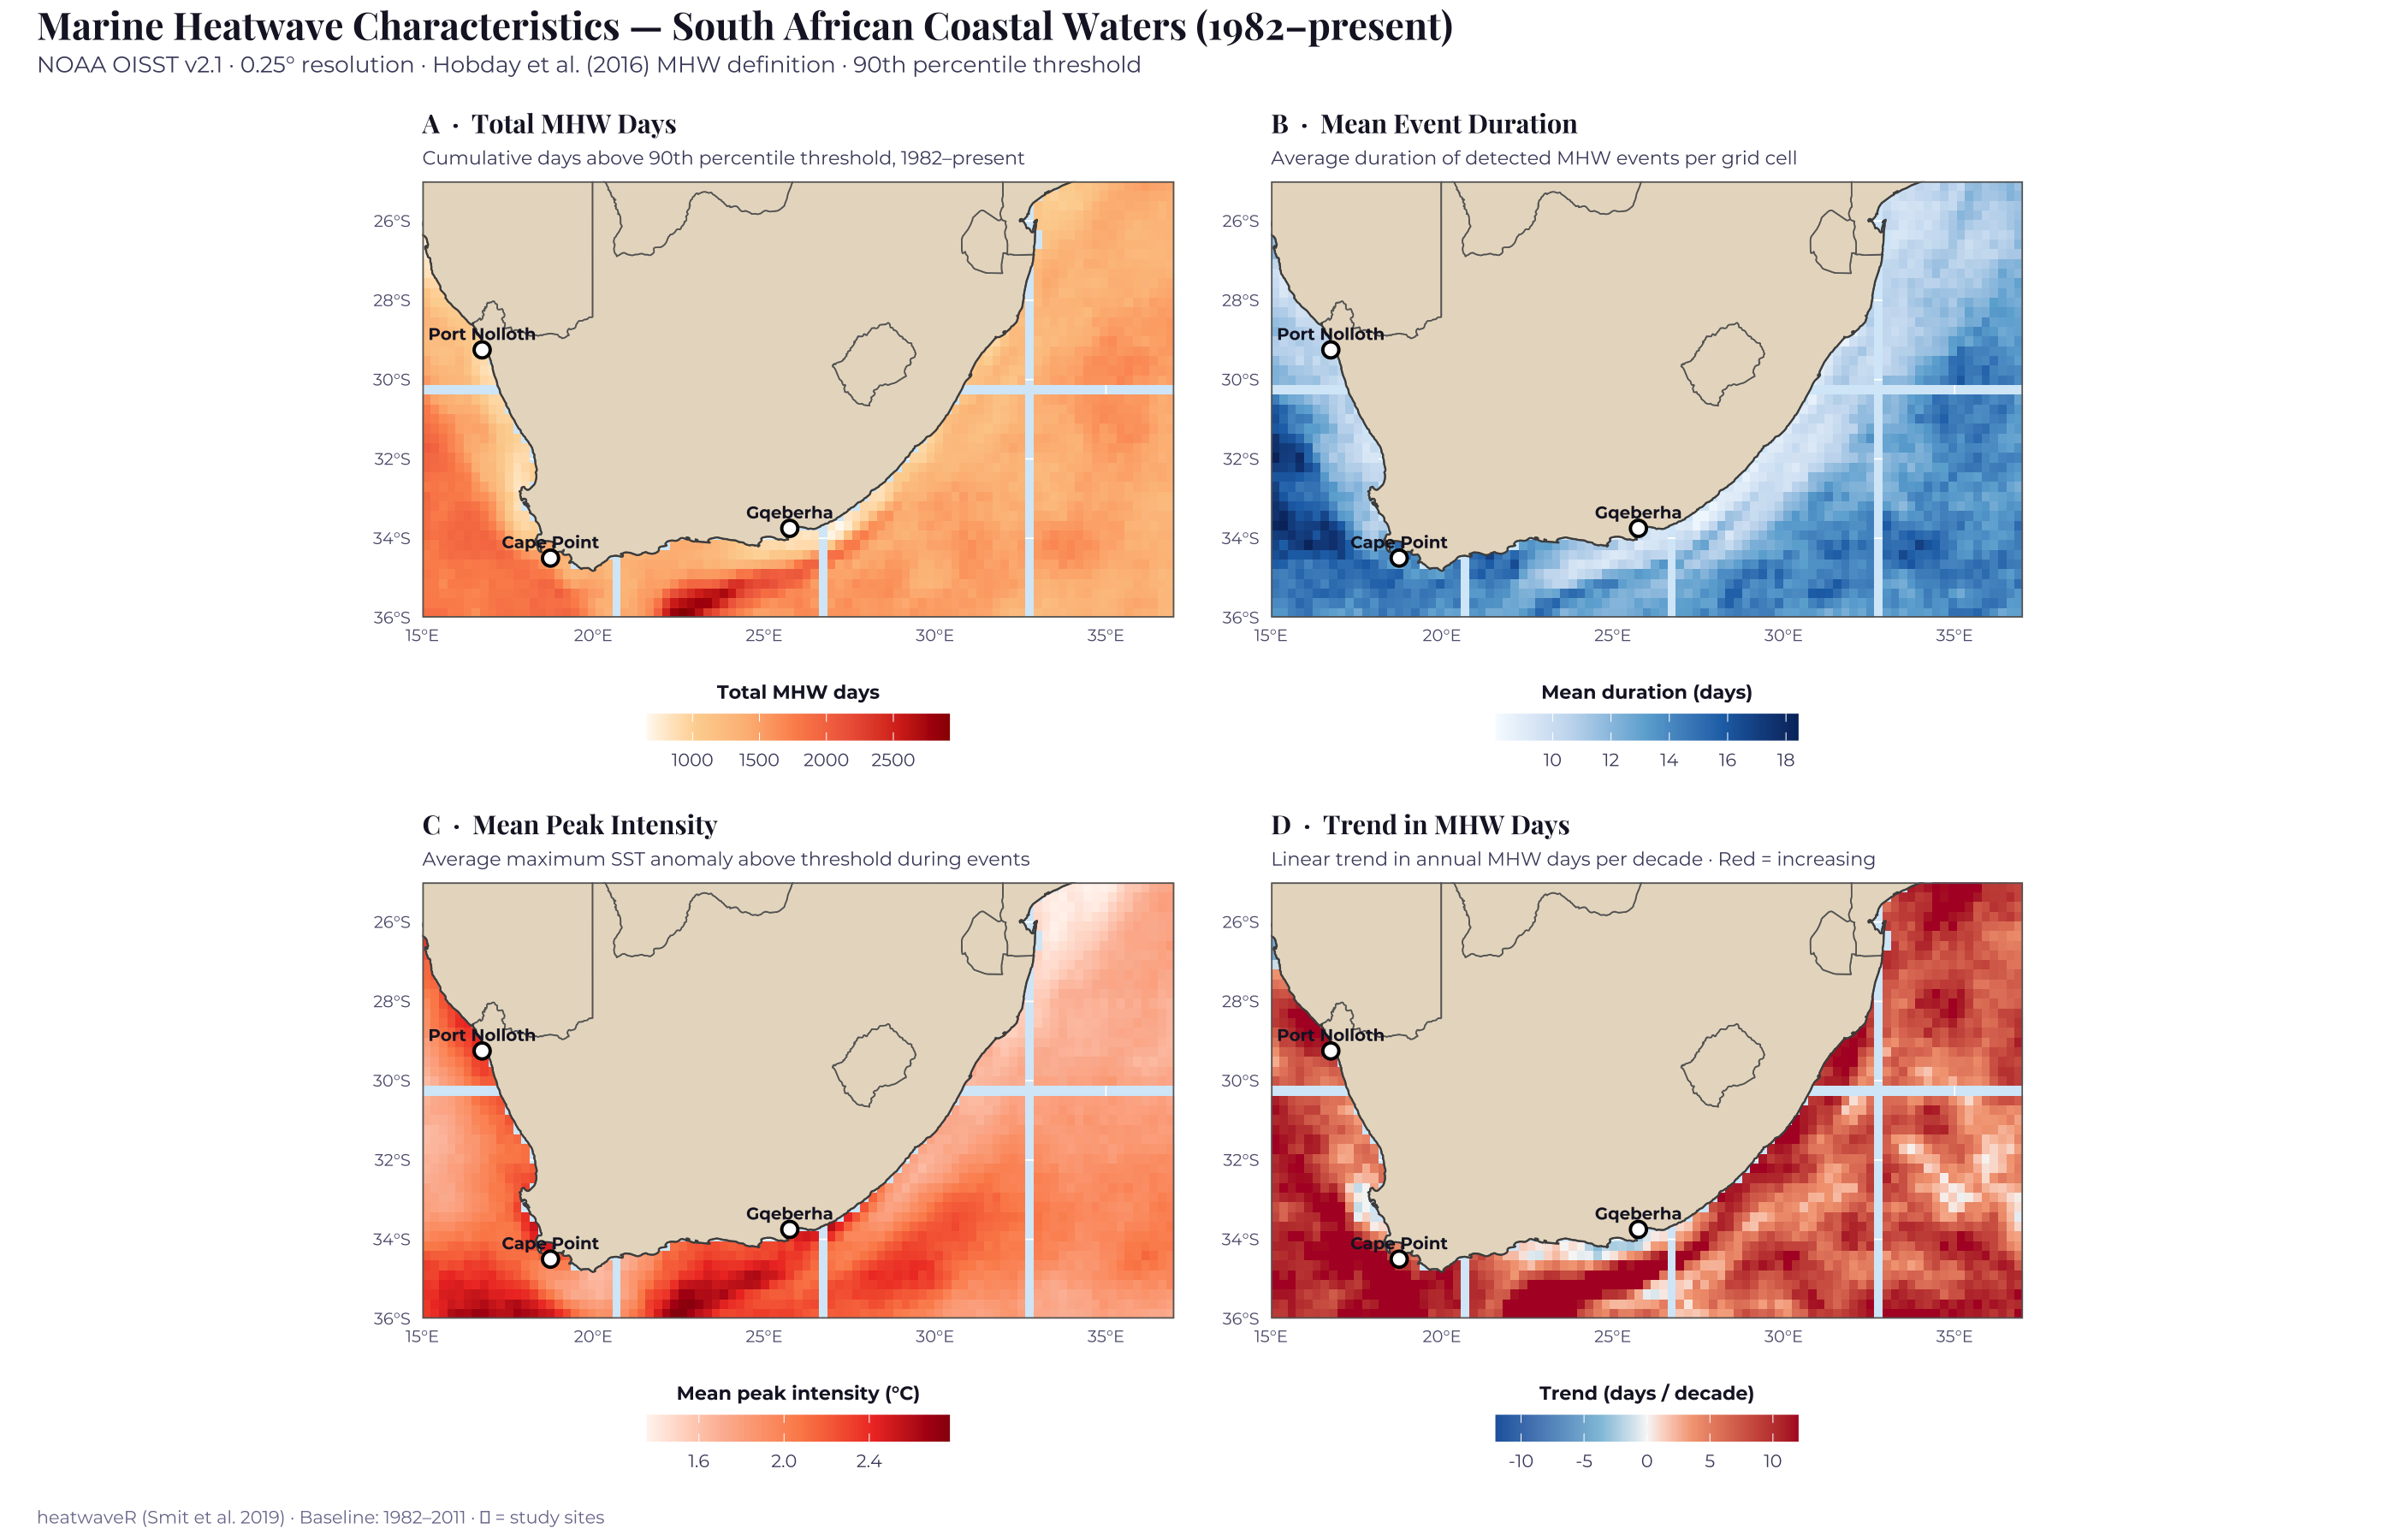

In [92]:
print(SpatialFigure)